In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F


In [2]:

class CBOW_NegativeSampling(nn.Module):
    def __init__(self, vocab_size, embed_size, window_size=2):
        super(CBOW_NegativeSampling, self).__init__()
        self.vocab_size = vocab_size
        self.embed_size = embed_size
        self.window_size = window_size
        
        # 优化点 1：双 Embedding 表架构
        # in_embed 替代原先的 embedding，用于提取上下文特征
        self.in_embed = nn.Embedding(vocab_size, embed_size)
        
        # out_embed 替代了原先低效的 nn.Linear
        # 它的本质是一个权重矩阵，但通过 Gather 操作按需拉取，极大地节省了显存带宽
        self.out_embed = nn.Embedding(vocab_size, embed_size)
        
        # 权重初始化
        nn.init.xavier_uniform_(self.in_embed.weight)
        # 输出层通常初始化为 0 或者很小的值
        nn.init.constant_(self.out_embed.weight, 0)

    def forward(self, context_indices, target_indices, neg_indices):
        """
        前向传播直接计算并返回 Loss
        :param context_indices: [batch_size, 2*window_size] 上下文
        :param target_indices:  [batch_size] 真实的中心词 (正样本)
        :param neg_indices:     [batch_size, K] 采样出的负样本
        :return: scalar loss
        """
        batch_size = context_indices.shape[0]

        # 1. 计算上下文向量 (求平均)
        # [B, 2W, D] -> [B, D]
        context_vecs = self.in_embed(context_indices)
        context_avg = context_vecs.mean(dim=1) 

        # 2. 处理正样本 (真实的中心词)
        # [B, D]
        pos_vecs = self.out_embed(target_indices)
        # 算子优化：按元素相乘后在特征维度求和，等价于逐样本做点积
        # pos_scores: [B]
        pos_scores = torch.sum(context_avg * pos_vecs, dim=1)
        
        # 3. 处理负样本
        # [B, K, D]
        neg_vecs = self.out_embed(neg_indices)
        # 算子优化：使用 bmm (Batch Matrix Multiplication) 批量计算负样本点积
        # context_avg.unsqueeze(2) 形状为 [B, D, 1]
        # bmm([B, K, D], [B, D, 1]) -> [B, K, 1] -> squeeze得到 [B, K]
        neg_scores = torch.bmm(neg_vecs, context_avg.unsqueeze(2)).squeeze(2)

        # 4. 计算 Negative Sampling Loss (使用 F.logsigmoid 保证数值稳定性)
        # 目标：最大化正样本被预测为 1 的概率，最大化负样本被预测为 0 的概率
        # 数学公式：- log(sigmoid(pos_scores)) - sum(log(sigmoid(-neg_scores)))
        pos_loss = -F.logsigmoid(pos_scores)
        neg_loss = -F.logsigmoid(-neg_scores).sum(dim=1)

        # 返回当前 Batch 的平均 Loss
        return (pos_loss + neg_loss).mean()

    def get_embedding(self):
        """
        训练完成后，通常将两张表相加或直接使用 in_embed 作为最终词向量
        """
        return self.in_embed.weight.data
    
    def Dataloader(self, corpus, vocab, batch_size, word_freqs, K=5):
        """
        生成训练数据：上下文 + 正样本(中心词) + 负样本
        :param word_freqs: 词频列表，索引与 vocab 对应
        :param K: 负样本数量
        """
        contexts, targets = [], []
        for i in range(self.window_size, len(corpus) - self.window_size):
            context = corpus[i - self.window_size:i] + corpus[i + 1:i + self.window_size + 1]
            target = corpus[i]
            contexts.append(context)
            targets.append(target)
        
        contexts = torch.tensor(contexts, dtype=torch.long)
        targets = torch.tensor(targets, dtype=torch.long)
        
        # --- 负采样核心逻辑 ---
        # 1. 计算 3/4 次方平滑概率
        word_freqs = torch.tensor(word_freqs, dtype=torch.float)
        smoothed_freqs = torch.pow(word_freqs, 0.75)
        sample_probs = smoothed_freqs / smoothed_freqs.sum()
        
        # 2. 批量采样出所有的负样本 [num_samples, K]
        # torch.multinomial 在底层是高度优化的 alias method 或 CDF 二分查找
        num_samples = len(targets)
        negatives = torch.multinomial(sample_probs, num_samples * K, replacement=True)
        negatives = negatives.view(num_samples, K)
        
        dataset = torch.utils.data.TensorDataset(contexts, targets, negatives)
        return torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    def train_epoch(self, dataloader, optimizer, device):
        self.train()
        total_loss = 0.0
        for context, target, negatives in dataloader:
            context = context.to(device)
            target = target.to(device)
            negatives = negatives.to(device)
            
            # 清空梯度
            optimizer.zero_grad()
            
            # 前向计算自动返回 loss
            loss = self.forward(context, target, negatives)
            
            # 反向传播和更新
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            
        return total_loss / len(dataloader)

In [3]:
import os
import collections
import re
from d2l import torch as d2l
from collections import defaultdict, Counter

os.chdir("../") 
from Subwords.Subwords_Vocab import Vocab as Vocab
from Subwords.Subwords_Vocab import load_corpus_time_machine as load_corpus_time_machine
from Subwords.Subwords_Vocab import train_epoch_ch8 as train_epoch_ch8
from Subwords.Subwords_Vocab import predict_ch8 as predict_ch8
from Subwords.Subwords_Vocab import load_data_time_machine as load_data_time_machine
from Subwords.Subwords_Vocab import train_ch8 as train_ch8


In [4]:
import numpy as np

def build_word_freqs_fast(corpus_ids, vocab_size):
    """
    极速词频统计：适用于 corpus_ids 已经是 Token ID 列表的情况
    :param corpus_ids: List[int] 或 np.ndarray，包含所有语料的 Token IDs
    :param vocab_size: 词表总大小
    :return: List[int]
    """
    # 将输入转为连续内存的 numpy 数组 (如果已经是则没有额外开销)
    ids_array = np.asarray(corpus_ids, dtype=np.int32)
    
    # bincount 是底层 C 实现的桶计数算子，速度极快
    # minlength 保证了输出数组的长度严格等于 vocab_size
    freqs_array = np.bincount(ids_array, minlength=vocab_size)
    
    return freqs_array.tolist()

In [ ]:
batch_size, num_steps = 32, 35
train_iter, vocab = load_data_time_machine(batch_size, num_steps)
corpus = train_iter.corpus

BPE训练进度: |█████████████████████████████-| 999/1000

In [6]:
word_freqs = build_word_freqs_fast(corpus, len(vocab))
embed_size = 128
model = CBOW_NegativeSampling(len(vocab), embed_size, window_size=2)

# 把 word_freqs 传进去，Dataloader 内部会计算 3/4 次方并构建多项式分布采样器
dataloader = model.Dataloader(
    corpus=corpus, 
    vocab=vocab, 
    batch_size=512, 
    word_freqs=word_freqs, 
    K=5  # 每个正样本配 5 个负样本
)
model.to('cuda' if torch.cuda.is_available() else 'cpu')
epochs = 100
for epoch in range(epochs):
    l = model.train_epoch(dataloader,
                optimizer=torch.optim.Adam(model.parameters(), lr=0.01),
                device='cuda' if torch.cuda.is_available() else 'cpu')
    
    total_epochs = epochs
    progress = (epoch + 1) / total_epochs
    bar_len = 30    
    filled_len = int(bar_len * progress)
    bar = "█" * filled_len + "-" * (bar_len - filled_len)
    print(f"\r[{bar}] {epoch + 1}/{total_epochs} loss {l:.4f}", end="", flush=True)
    if epoch + 1 == total_epochs:
        print()

[██████████████████████████████] 100/100 loss 0.3465


In [7]:
class GRUModel(nn.Module):
    # 新增 pretrained_embeddings 参数，控制是否冻结词向量 freeze_embed
    def __init__(self, pretrained_embeddings, hidden_size, output_size, freeze_embed=False):
        super(GRUModel, self).__init__()
        
        # 1. 核心接入点：挂载预训练的词向量表
        # pretrained_embeddings 是一个形状为 [vocab_size, embed_size] 的 Tensor
        self.embedding = nn.Embedding.from_pretrained(
            pretrained_embeddings, 
            freeze=freeze_embed  # True: 词向量固定不变; False: 随下游任务微调 (Fine-tune)
        )
        
        # 此时的 input_size 不再是词表大小，而是词向量的维度 (embed_size)
        self.input_size = self.embedding.embedding_dim
        self.hidden_size = hidden_size
        self.output_size = output_size

        # --- 这里的 input_size 已经被替换为 embed_size ---
        self.W_xr = nn.Parameter(torch.randn(self.input_size, hidden_size) * 0.01)
        self.W_hr = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.01)
        self.b_r = nn.Parameter(torch.zeros(hidden_size))

        self.W_xz = nn.Parameter(torch.randn(self.input_size, hidden_size) * 0.01)
        self.W_hz = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.01)
        self.b_z = nn.Parameter(torch.zeros(hidden_size))

        self.W_xh = nn.Parameter(torch.randn(self.input_size, hidden_size) * 0.01)
        self.W_hh = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.01)
        self.b_h = nn.Parameter(torch.zeros(hidden_size))

        self.W_hq = nn.Parameter(torch.randn(hidden_size, output_size) * 0.01)
        self.b_q = nn.Parameter(torch.zeros(output_size))
    
    def init_hidden(self, batch_size, device):
        return (torch.zeros(batch_size, self.hidden_size, device=device),)

    def forward(self, inputs, state):
        """
        :param inputs: 形状 [batch_size, seq_len] 的 Token IDs
        :param state: 初始隐状态
        """
        # 2. 算子优化：彻底移除 F.one_hot
        # 将 inputs 转置为 [seq_len, batch_size]，然后查表
        # embed_inputs 形状变为: [seq_len, batch_size, embed_size]
        embed_inputs = self.embedding(inputs.T)
        
        hidden, = state
        outputs = []
        
        # 按时间步 (seq_len) 遍历，x 的形状为 [batch_size, embed_size]
        for x in embed_inputs:
            # 内部的矩阵运算无需任何修改，因为 W_x 系列矩阵的维度已经在 __init__ 中对齐
            R = torch.sigmoid(x @ self.W_xr + hidden @ self.W_hr + self.b_r)
            Z = torch.sigmoid(x @ self.W_xz + hidden @ self.W_hz + self.b_z)
            H_tilda = torch.tanh(x @ self.W_xh + (R * hidden) @ self.W_hh + self.b_h)
            hidden = Z * hidden + (1 - Z) * H_tilda
            
            y = hidden @ self.W_hq + self.b_q
            outputs.append(y)
            
        return torch.cat(outputs, dim=0), (hidden,)

In [8]:
pretrained_weights = model.get_embedding() # tensor [vocab_size, embed_size]

# 2. 初始化你的 GRU 模型
gru_model = GRUModel(
    pretrained_embeddings=pretrained_weights, 
    hidden_size=256, 
    output_size=len(vocab), 
    freeze_embed=False # 推荐 False，让词向量在具体的文本分类/生成任务中继续微调
)

In [ ]:
gru_model.to('cuda' if torch.cuda.is_available() else 'cpu')


困惑度 1.6, 2.1 词元/秒 cuda:0
['time</w>', 'traveller</w>']
time traveller ' s face . iii ' i told some of you last thursday of the principles of the time machine , and showed you the actual thing itself , incomplete in the 
['traveller</w>']
traveller looked at us , and then at the mechanism . ' well ? ' said the psychologist . ' this little affair , ' said the time traveller , resting his elbows upon the table and pressing his hands together 


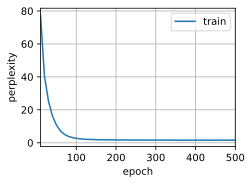

In [11]:

num_epochs, lr = 500, 1
device = d2l.try_gpu()
gru_model = gru_model.to(device)
train_ch8(gru_model, train_iter, vocab, lr, num_epochs, device)

In [15]:
predict2 = lambda prefix: predict_ch8(prefix, 500, gru_model, vocab, device)
predict2('And now I was to see the most weird and horrible thing,')

['and</w>', 'now</w>', 'i</w>', 'was</w>', 'to</w>', 'see</w>', 'the</w>', 'most</w>', 'we', 'ir', 'd</w>', 'and</w>', 'hor', 'ri', 'ble</w>', 'thing</w>', ',</w>']


"and now i was to see the most weird and horrible thing , i think , of all that i beheld in that future age . this whole space was as bright as day with the reflection of the fire . in the centre was a hillock or tumulus , surmounted by a scorched hawthorn . beyond this was another arm of the burning forest , with yellow tongues already writhing from it , completely encircling the space with a fence of fire . upon the hill - side were some thirty or forty morlocks , dazzled by the light and heat , and blundering hither and thither against each other in their bewilderment . at first i did not realize their blindness , and struck furiously at them with my bar , in a frenzy of fear , as they approached me , killing one and crippling several more . but when i had watched the gestures of one of them groping under the hawthorn against the red sky , and heard their moans , i was assured of their absolute helplessness and misery in the glare , and i struck no more of them . ' yet every now and